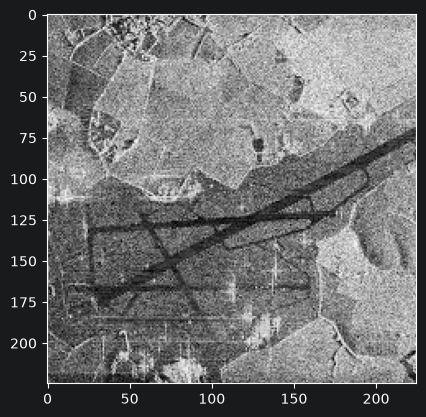

In [1]:
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")


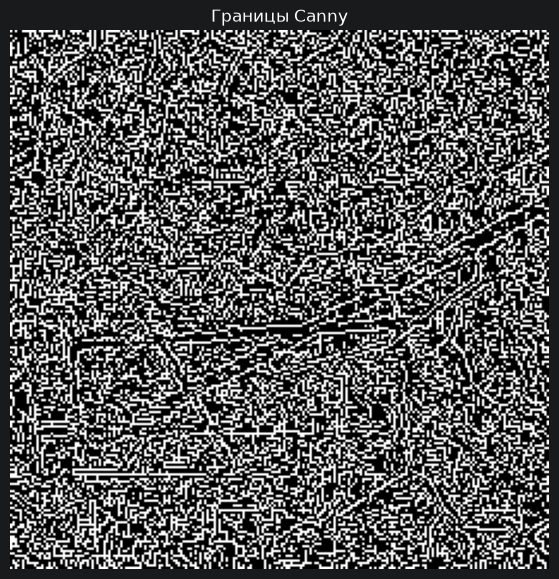

In [6]:
edges = cv2.Canny(image_gray, 50, 150)

plt.figure(figsize=(7, 7))
plt.imshow(edges, cmap='gray')
plt.title('Границы Canny')
plt.axis('off')
plt.show()


Длина наиболее протяженного участка: 315.37


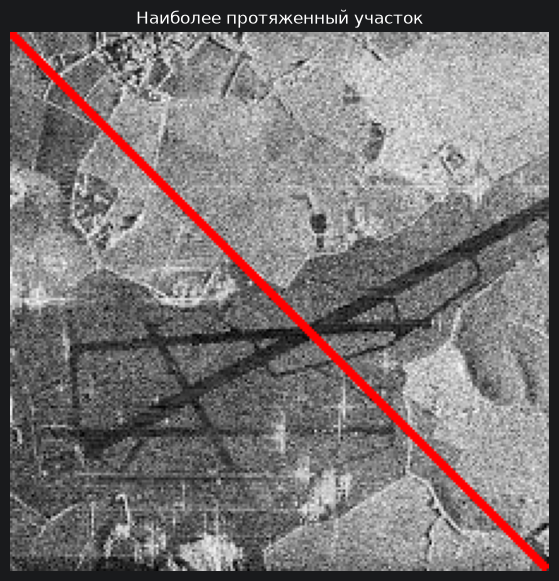

In [9]:
# Вероятностное преобразование Хафа
lines = cv2.HoughLinesP(edges,rho=1,theta=np.pi / 180,threshold=40,minLineLength=30,maxLineGap=15)

result = image.copy()

# Поиск наиболее протяженной линии
max_length = 0
longest_line = None

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line
        length = np.hypot(x2 - x1, y2 - y1)
        if length > max_length:
            max_length = length
            longest_line = (x1, y1, x2, y2)
    print("Длина наиболее протяженного участка:", round(max_length, 2))
    # Выделяем найденную линию
    x1, y1, x2, y2 = longest_line
    cv2.line(
        result,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2
    )

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(7, 7))
plt.imshow(result_rgb)
plt.title("Наиболее протяженный участок")
plt.axis("off")
plt.show()

Исследование алгоритмов бинаризации

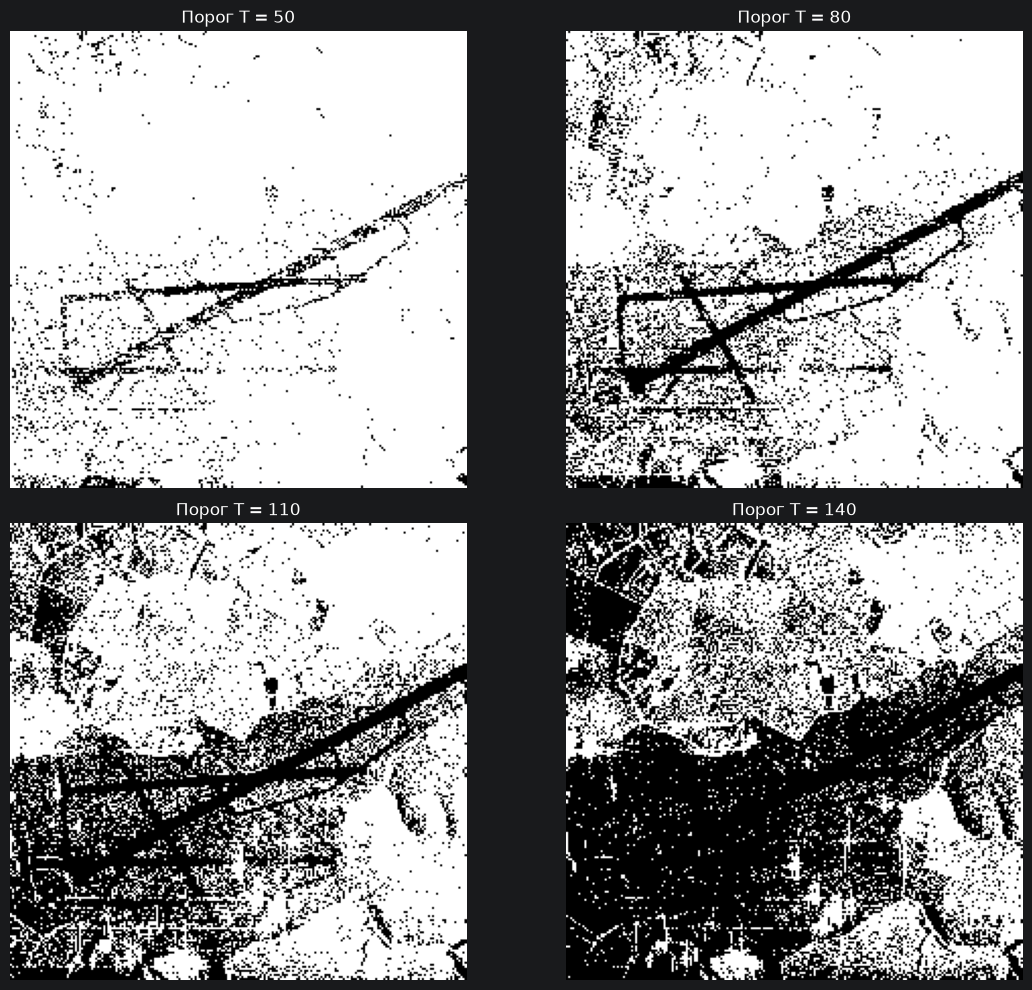

In [10]:
thresholds = [50, 80, 110, 140]
plt.figure(figsize=(12, 10))

for i, T in enumerate(thresholds):
    _, binary = cv2.threshold(image_gray,T,255,cv2.THRESH_BINARY)
    plt.subplot(2, 2, i + 1)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Порог T = {T}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Порог, найденный методом Otsu: 129.0


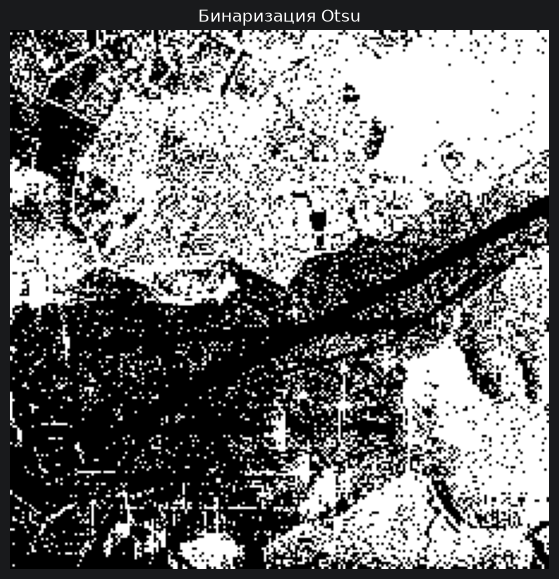

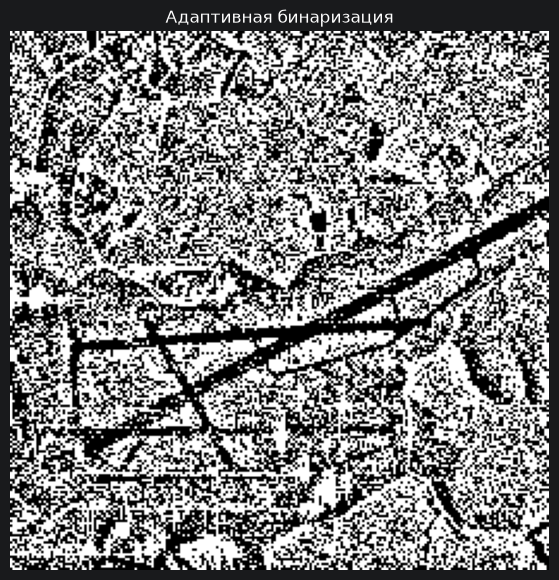

In [12]:
#Бинаризация Otsu
otsu_threshold, otsu_img = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Порог, найденный методом Otsu:", otsu_threshold)
plt.figure(figsize=(7, 7))
plt.imshow(otsu_img, cmap='gray')
plt.title('Бинаризация Otsu')
plt.axis('off')
plt.show()

#Бинаризация адаптивная
adaptive = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,31,5)
plt.figure(figsize=(7, 7))
plt.imshow(adaptive, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')
plt.show()

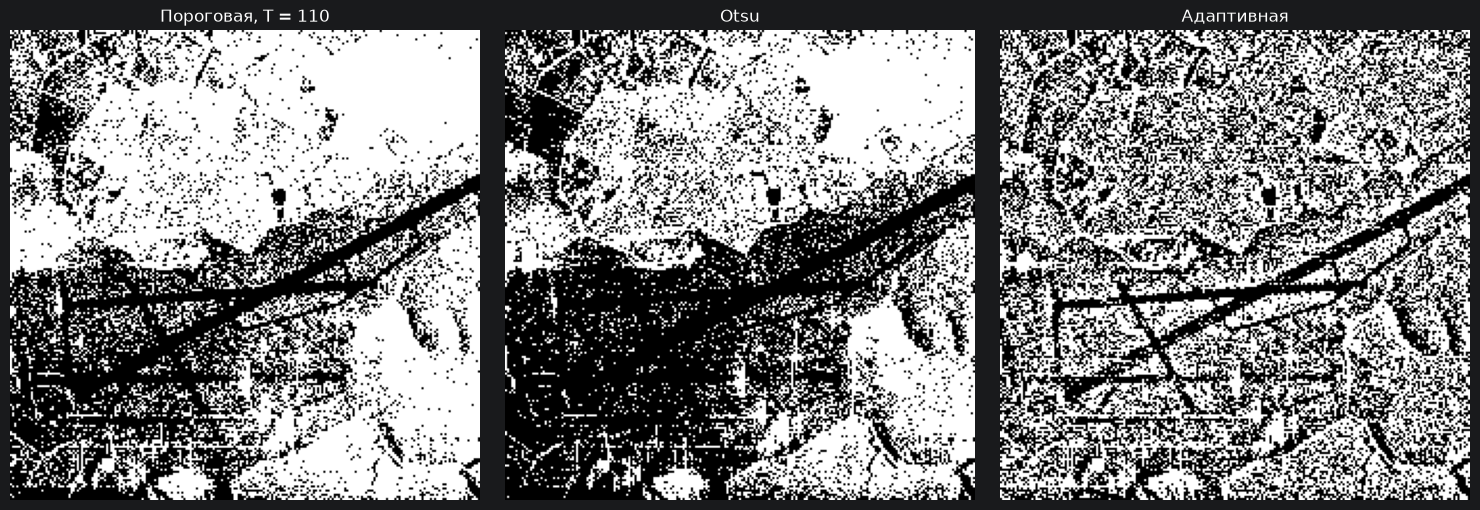

In [13]:
#Сравнение результатов бинаризации
_, binary_110 = cv2.threshold(image_gray,110,255,cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_110, cmap='gray')
plt.title('Пороговая, T = 110')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(otsu_img, cmap='gray')
plt.title('Otsu')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive, cmap='gray')
plt.title('Адаптивная')
plt.axis('off')

plt.tight_layout()
plt.show()